In [ ]:
from examples.seismic.datasets import VelocityModel, SeismogramDataset
import numpy as np
from examples.seismic.acoustic import AcousticWaveSolver
from matplotlib import pyplot as plt
from examples.seismic import SeismicModel, AcquisitionGeometry
from devito import configuration
configuration["platform"] = "nvidiaX"
configuration["language"] = "openacc"

PATH_MODEL = "../data/South_ForMigr_2.dat"
PATH_DATA = path = "../data/21-20.sgy"
SO = 4

In [2]:
dataset = SeismogramDataset(PATH_DATA, "rec")
# for i in range(len(dataset)):
#     dataset.plot_spectrum_map(i, db_scale=False, n_bins=250, figsize=(8, 2), max_freq=8000, quant=1, cmap='jet')
xmin, xmax = min(dataset.x_coords.min(), dataset.opposite_x.min()), max(dataset.x_coords.max(), dataset.opposite_x.max())
print(xmin, xmax)

# dataset.create_spectrum_animation(figsize=(8,2), cmap='jet', max_freq=2000)

61.11 95.55


In [3]:
spacing = (0.025, 0.025)
velmodel = VelocityModel(PATH_MODEL, dx=spacing[0], dz=spacing[1], clip=True, xmin=xmin-3, xmax=xmax+3, zmin=-318)
velmodel.pad_left(4)
velmodel.pad_right(8*int(0.5/0.025))
velmodel.pad_bottom(50*int(0.5/0.025))
velmodel.pad_top(7*int(0.5/0.025))

vp = velmodel.vp.T
print(np.max(vp))
print(np.min(vp))

dx_critical = 500/(10*2000)
print(dx_critical)

(2298, 1462)
4.495380000000004
0.52462
0.025


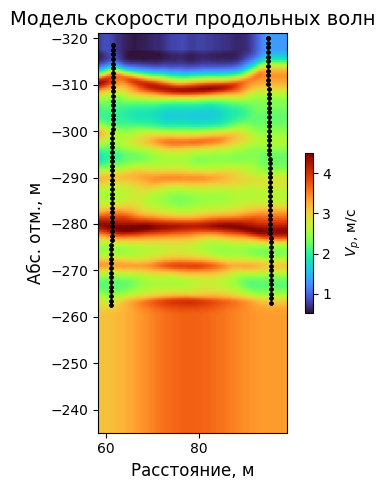

In [4]:
fig, axs = velmodel.plot_vp(show=False, figsize=(9, 5), dpi=100)
axs[0].scatter(dataset.x_coords, -dataset.elevations, c='k', s=2)
axs[0].scatter(dataset.opposite_x, -dataset.opposite_elev, c='k', s=2)
plt.show()

In [5]:
nbl = 500
origin = velmodel.x[0], velmodel.z[0]
vp = velmodel.vp.T

model = SeismicModel(
    vp=vp,
    origin=origin,
    shape=vp.shape,
    spacing=spacing,
    space_order=SO,
    nbl=nbl,
    bcs="damp",
    fs=True,
)

Operator `initdamp` ran in 0.01 s


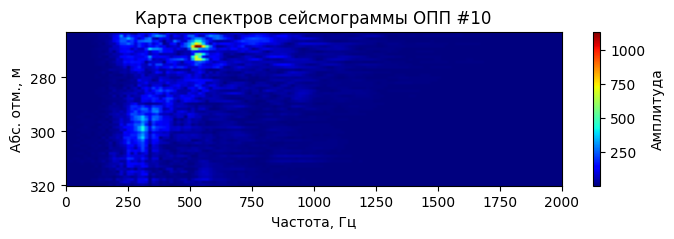

In [6]:
dataset.plot_spectrum_map(10, figsize=(8,2), cmap='jet', max_freq=2000)

In [ ]:
d_2, sx, sz, rec_x, rec_z = dataset[10]
sz *= -1
rec_z *= -1

t0 = 0
tn = dataset._t_max

src_pos = np.array([sx, sz])[None, :]
rec_pos = np.vstack([rec_x, rec_z]).T

f0=0.5

geometry =  AcquisitionGeometry(model, rec_pos, src_pos, t0, tn, f0=f0, src_type="Ricker")

solver = AcousticWaveSolver(model, geometry, space_order=4)
smooth_d, _, _ = solver.forward(vp=model.vp)

In [ ]:
from examples.seismic import plot_shotrecord

plot_shotrecord(smooth_d.data, model, t0, tn)